# Task 0:


1.   What does the NEIG-##### actaully represent?
 - It's the Jira issue key. "NEIG" is the name of the jira project, and the number is a counter that goes up by one each time any record is created in that prject. SO it identifies one ticket, not a family or a person.
2.   Why arent ticket numbers sequential per family?
- The counter is shared by everyone, so a family's tickets get whatever number is next in order when staff create them. so when a family visits again there has been other tickets issued between their two visits.  
3. What does Issue Type tell you about new intakes vs. sub-tickets?  
If they have Parent key it means they are sub-tickets. and the intakes have the name new profile, connected Neighbor Profile, Flourishing Neighbor Profile.






# Task 1:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
intakes = pd.read_csv("/content/drive/MyDrive/cleaned_intakes_masked.csv")
intakes.head()

,PID,PID Match Basis,Summary,Issue key,Issue id,Issue Type,Status,Resolution,Reporter,Reporter Id,...,Custom field ([CHART] Date of First Response),Custom field ([CHART] Time in Status),Comment,Comment.1,Comment.2,Parent,Parent key,Parent summary,Status Category,Status Category Changed
0,P0289,Name + DOB,Person P0289,NEIG-19349,60769,New Profile,Initial Contact,NaN,Johanna South,712020:3b2c2185-c76f-4d90-ad8c-9e260c73c318,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,In Progress,12/Aug/26 1:37 PM
1,P0352,Name + DOB,Person P0352,NEIG-19336,60756,New Profile,Second Contact,NaN,Johanna South,712020:3b2c2185-c76f-4d90-ad8c-9e260c73c318,...,2026-08-12 18:34:29.69,NaN,12/Aug/26 2:34 PM;712020:7919ac37-40c1-4b22-a8...,NaN,NaN,NaN,NaN,NaN,In Progress,12/Aug/26 1:37 PM
2,P0308,Name + DOB,Person P0308,NEIG-19324,60744,New Profile,Initial Contact,NaN,Johanna South,712020:3b2c2185-c76f-4d90-ad8c-9e260c73c318,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,In Progress,12/Aug/26 1:37 PM
3,P0253,Name + DOB,Person P0253,NEIG-19311,60731,New Profile,Second Contact,NaN,Johanna South,712020:3b2c2185-c76f-4d90-ad8c-9e260c73c318,...,2026-08-11 19:11:08.805,NaN,11/Aug/26 3:11 PM;712020:7919ac37-40c1-4b22-a8...,NaN,NaN,NaN,NaN,NaN,In Progress,11/Aug/26 3:08 PM
4,P0102,Name + DOB,Person P0102,NEIG-19296,60716,New Profile,Initial Contact,NaN,Johanna South,712020:3b2c2185-c76f-4d90-ad8c-9e260c73c318,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,In Progress,11/Aug/26 3:08 PM


In [ ]:
intakes.shape

(639, 93)

In [ ]:
for c in intakes.columns:
    print(c, "| missing:", round(intakes[c].isna().mean(), 2), "| unique values:", intakes[c].nunique())

PID | missing: 0.0 | unique values: 439
PID Match Basis | missing: 0.0 | unique values: 3
Summary | missing: 0.0 | unique values: 439
Issue key | missing: 0.0 | unique values: 639
Issue id | missing: 0.0 | unique values: 639
Issue Type | missing: 0.0 | unique values: 23
Status | missing: 0.0 | unique values: 20
Resolution | missing: 0.89 | unique values: 2
Reporter | missing: 0.0 | unique values: 3
Reporter Id | missing: 0.0 | unique values: 3
Creator | missing: 0.0 | unique values: 3
Creator Id | missing: 0.0 | unique values: 3
Created | missing: 0.0 | unique values: 619
Updated | missing: 0.0 | unique values: 487
Resolved | missing: 0.89 | unique values: 72
Labels.1 | missing: 0.0 | unique values: 40
Labels.2 | missing: 0.01 | unique values: 47
Labels.3 | missing: 0.07 | unique values: 45
Labels.4 | missing: 0.29 | unique values: 36
Labels.5 | missing: 0.61 | unique values: 24
Labels.6 | missing: 0.82 | unique values: 19
Watchers | missing: 0.0 | unique values: 4
Watchers.1 | missing

In [ ]:
for c in ["Labels.1", "Labels.2", "Labels.3", "Labels.4", "Labels.5", "Labels.6"]:
    print(c, "| missing:", round(intakes[c].isna().mean(), 2))
    print(intakes[c].value_counts().head(5))
    print()

Labels.1 | missing: 0.0
Labels.1
JCPS              136
Caretaker          62
Aetna              55
Passport           39
Eviction_Court     38
Name: count, dtype: int64

Labels.2 | missing: 0.01
Labels.2
JCPS               135
Passport           110
SLCM                74
LMHA                55
Humana-Medicaid     28
Name: count, dtype: int64

Labels.3 | missing: 0.07
Labels.3
SLCM        141
Passport     81
SNAP         61
JCPS         59
LMHA         34
Name: count, dtype: int64

Labels.4 | missing: 0.29
Labels.4
SNAP                            106
SLCM                             61
Passport                         45
Workforce-Unemployed             29
Workforce-FinancialStability     27
Name: count, dtype: int64

Labels.5 | missing: 0.61
Labels.5
SNAP                            58
SLCM                            30
SSDI                            23
Passport                        19
Workforce-FinancialStability    19
Name: count, dtype: int64

Labels.6 | missing: 0.82
Labels.6
SN

| Column | Decision | Reason |
|---|---|---|
| PID | Needed | Person identifier; links tickets to the same person for Q4 and PID-based figures |
| PID Match Basis | Optional | Could support Q5 data quality by showing PID reliability |
| Summary | Drop | Not relevant to the five questions (also raises a data privacy concern — appears to contain names; see Q5) |
| Issue key | Needed | Ticket identifier; links to household file |
| Issue id | Drop | Internal system/Jira field |
| Issue Type | Needed | Distinguishes profiles vs sub-tickets; needed for Task 0 and row-scope decisions |
| Status | Optional | Could support Task 0 by showing ticket lifecycle, not a case outcome |
| Resolution | Drop | Mostly missing (89%) |
| Reporter | Drop | Internal system/Jira field |
| Reporter Id | Drop | Internal system/Jira field |
| Creator | Drop | Internal system/Jira field |
| Creator Id | Drop | Internal system/Jira field |
| Created | Needed | Ticket creation date; used directly in Task 0 |
| Updated | Drop | Internal system/Jira field |
| Resolved | Drop | Mostly missing (89%) |
| Labels.1 | Optional | Could support Q1/Q3 context — program/insurance/school tags, nearly complete |
| Labels.2 | Optional | Same tag pattern as Labels.1, nearly complete |
| Labels.3 | Optional | Same tag pattern as Labels.1, mostly complete |
| Labels.4 | Optional | Same tag pattern, sparser (29% missing) |
| Labels.5 | Drop | Mostly missing (61%) |
| Labels.6 | Drop | Mostly missing (82%) |
| Watchers | Drop | Internal system/Jira field |
| Watchers.1 | Drop | Internal system/Jira field |
| Watchers Id | Drop | Internal system/Jira field |
| Watchers Id.1 | Drop | Internal system/Jira field |
| # Additional Household Members | Needed | Core field for Q3 household composition |
| Custom field (City) | Optional | Could support Q1 geographic breakdown, overlaps with Zip Code |
| Custom field (Community Ministry) | Optional | Could support Q1 if referral source relates to housing outcomes |
| Custom field (Court Date) | Drop | Mostly missing (89%); flagged as possible Optional if we explore eviction timing for Q1 |
| Custom field (Current Employer) | Drop | Mostly missing (63%), free text |
| Age at Intake | Needed | Core demographic field for Q3 |
| Custom field (Employment Status) | Needed | Used directly in Q2 |
| Custom field (Eviction Reason) | Optional | Could support Q1 by explaining why eviction risk occurred |
| Custom field (Eviction Status) | Needed | Core field for Q1 and Figures 1-2 |
| Custom field (Gender) | Needed | Core demographic field for Q3 |
| Custom field (Goals) | Optional | Could support "what did you get to know?" — qualitative case detail, most-complete slot |
| Custom field (Goals).1 | Drop | Redundant with Custom field (Goals) |
| Custom field (Goals).2 | Drop | Redundant with Custom field (Goals) |
| Custom field (Goals).3 | Drop | Redundant with Custom field (Goals) |
| Custom field (Household Identities) | Optional | Could support Q3 household composition |
| Custom field (Household Identities).1 | Drop | Redundant with Custom field (Household Identities) |
| Custom field (Household repairs required?) | Optional | Could support Q1 if exploring housing quality beyond eviction/rent |
| Custom field (Housing Status) | Needed | Core field for Q1 and Figures 1-2 |
| Custom field (Income Amount) | Needed | Used directly in Q2 |
| Custom field (Insurance Provider for Family) | Drop | Not relevant to the five questions |
| Custom field (Intake Date) | Optional | Redundant with Created, could support Task 0 as a cross-check |
| Has LG&E Account on File | Drop | Not relevant to the five questions (utility data excluded from Part 1) |
| Custom field (Landlord Name) | Drop | Not relevant to the five questions |
| Custom field (Loss of Income Causation) | Optional | Could support Q2 by explaining the source of financial hardship |
| Custom field (Loss of Income Causation).1 | Drop | Redundant with base field |
| Custom field (Loss of Income Causation).2 | Drop | Redundant with base field |
| Custom field (Loss of Income Causation).3 | Drop | Redundant with base field |
| Custom field (Main reason Neighbor stopped paying rent) | Optional | Could support Q1 with more detail on eviction cause |
| Custom field (Monthly Rent) | Needed | Core field for Q1 housing severity |
| Has Email on File | Drop | Internal system/Jira field |
| Has Phone on File | Drop | Internal system/Jira field |
| Custom field (Other Professionals Detail) | Drop | Mostly missing (81%), free text |
| Custom field (Other professionals helping with goals?) | Drop | Not relevant to the five questions |
| Custom field (Past Due Rent) | Needed | Core field for Q1 housing severity |
| Custom field (People in Household 17 and Under) | Needed | Core field for Q3 household composition |
| Custom field (People in Household 18+) | Needed | Core field for Q3 household composition |
| Custom field (People in Household 65+) | Optional | Could support Q3 for a fuller household picture |
| Custom field (Preferred method of contact) | Drop | Internal system/Jira field |
| Custom field (Preferred method of contact).1 | Drop | Redundant with base field |
| Custom field (Primary Insurance) | Drop | Not relevant to the five questions |
| Custom field (Primary Language Spoken in Home) | Optional | Could support Q3 if language diversity is relevant to household composition |
| Custom field (Pronoun) | Drop | Not relevant to the five questions |
| Custom field (Race/Ethnicity) | Needed | Core demographic field for Q3 |
| Custom field (Rank) | Drop | Internal system/Jira field (board sort order), also functions as an identifier |
| Custom field (Rent Intake Form Goals) | Drop | Mostly missing (73%), redundant with Custom field (Goals) |
| Custom field (Rent Intake Form Goals).1 | Drop | Redundant with base field |
| Custom field (Rent Intake Form Goals).2 | Drop | Redundant with base field |
| Custom field (Rent Intake Form Goals).3 | Drop | Redundant with base field |
| Custom field (Rent-to-Income %) | Optional | Could support Q1 housing severity directly, when present |
| Custom field (Response Method) | Drop | Internal system/Jira field |
| Custom field (Response Method).1 | Drop | Redundant with base field |
| Custom field (Section 8 or Housing Voucher) | Needed | Core field for Q1 housing status |
| Custom field (Source of income) | Needed | Used directly in Q2 |
| Custom field (Source of income).1 | Drop | Redundant with base field |
| Custom field (State) | Drop | Not relevant to the five questions (likely all Kentucky) |
| Custom field (Utility Past Due) | Drop | Not relevant to the five questions (utility data excluded from Part 1) |
| Has Water Account on File | Drop | Not relevant to the five questions (utility data excluded from Part 1) |
| Custom field (Zip Code) | Needed | Used directly in Q1 geographic breakdown |
| Custom field ([CHART] Date of First Response) | Drop | Internal system/Jira field |
| Custom field ([CHART] Time in Status) | Drop | Internal system/Jira field |
| Comment | Optional | Could support "what did you get to know?" — qualitative case notes |
| Comment.1 | Drop | Redundant with Comment |
| Comment.2 | Drop | Redundant with Comment |
| Parent | Drop | Identifier, duplicates Parent key |
| Parent key | Needed | Links sub-tickets to their profile; needed for Task 0 and row-scope decisions |
| Parent summary | Drop | Not relevant to the five questions (also raises a data privacy concern — appears to contain names; see Q5) |
| Status Category | Optional | Could support Task 0 as a simplified status grouping |
| Status Category Changed | Drop | Internal system/Jira field |

# Figure 1

In [ ]:
#step1: Look at all issue type categories and how many rows each has
print(intakes["Issue Type"].value_counts())


Issue Type
New Profile                                   378
Rent Assistance Care Path                     112
Connected Neighbor Profile                     44
House Navigation Care Path                     24
Basic Supplies                                 17
Utility Care Path                              12
Other                                           9
Legal Assistance Care Path                      7
Food Care Path                                  5
Transportation Care Path                        5
Flourishing Neighbor Profile                    4
Medical Costs or Bills                          3
Digital Access                                  3
Eviction Prevention Care Path                   3
Child Care Path                                 2
Play Cousins Care Path                          2
Pregnancy/Postpartum Care Path                  2
Healthcare Navigation Path                      2
Foreclosure Prevention/Mortgage Assistance      1
Job Search/Workforce Development Care P

In [ ]:
#step 2: Check which Issue Types have a Parent key filled in.
# Types with ~0 parents are "original" tickets (a new intake visit).
# Types where rows have a parent are follow-up requests tied to an existing visit.
print(intakes.groupby("Issue Type")["Parent key"].apply(lambda x: x.notna().sum()))

Issue Type
Basic Supplies                                 17
Care Plan                                       1
Case Management Navigation Path                 1
Child Care Path                                 2
Children's Welfare (CPS)                        1
Connected Neighbor Profile                      0
Digital Access                                  3
Eviction Prevention Care Path                   3
Flourishing Neighbor Profile                    0
Food Care Path                                  5
Foreclosure Prevention/Mortgage Assistance      1
Healthcare Navigation Path                      2
House Navigation Care Path                     24
Job Search/Workforce Development Care Path      1
Legal Assistance Care Path                      7
Medical Costs or Bills                          3
New Profile                                     0
Other                                           9
Play Cousins Care Path                          2
Pregnancy/Postpartum Care Path         

In [ ]:
# Based on the two checks above (from Task 0): New Profile, Connected Neighbor Profile,and Flourishing Neighbor Profile have no Parent key, meaning they are the original
# intake tickets. Every other Issue Type is a sub-ticket (a follow-up request) tied
# back to one of these three. So we treat these three types as "one case = one visit."
profiles = intakes[intakes["Issue Type"].isin(["New Profile", "Connected Neighbor Profile", "Flourishing Neighbor Profile"])]
print(len(profiles))

426


In [ ]:
#step 3: A family counts as "in crisis" if they are currently being evicted, or if they are unhoused (either condition is enough).
crisis = (profiles["Custom field (Eviction Status)"] == "Currently being evicted") | (profiles["Custom field (Housing Status)"] == "Unhoused")
print(crisis.value_counts())

False    306
True     120
Name: count, dtype: int64


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'module 2', 'CS430_NYC_Airbnb_EDA_Visualization_Student.ipynb', 'cleaned_intakes_masked.csv', 'household_members_long_v2.csv', 'module 3', '.ipynb_checkpoints', 'cs 430 figure 1.png', 'Figure2.png', 'CS430_Multiclass_Logistic_Regression_Softmax_Dry_Bean_Student.ipynb']


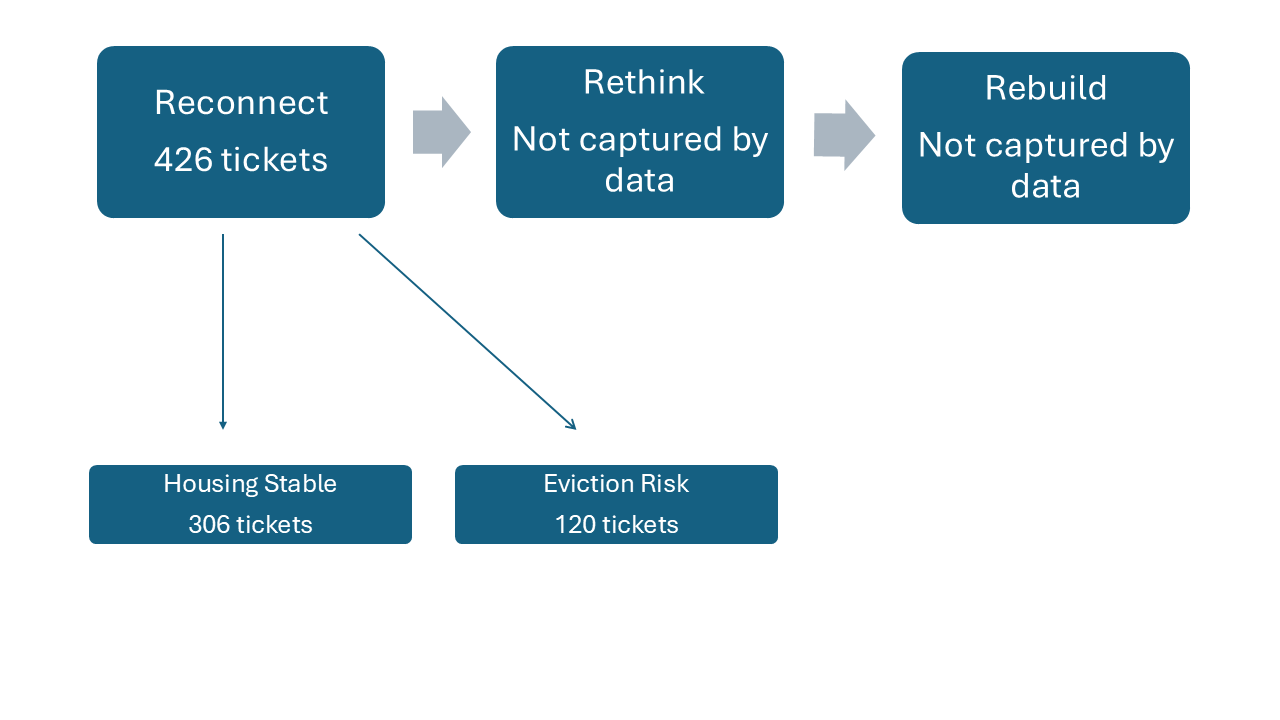

In [ ]:
from IPython.display import Image, display
display(Image('/content/drive/MyDrive/cs 430 figure 1.png'))


# Figure 2 :

In [ ]:
# step 1: same as figure 1 Get only the "real visit" tickets (profiles)
profiles = profiles.copy()
# Step 2: Mark each row as "urgent" or not.
# Urgent = currently being evicted, OR currently unhoused (either counts).
profiles["urgent"] = crisis


In [ ]:
# Step 3: Count how many profile-type tickets each person (PID) has.
# This tells us who is a repeat visitor.
pid_counts = profiles["PID"].value_counts()


In [ ]:
# Step 4: Mark each row as "chronic" or not.
# Chronic = this person's PID appears on 2+ profile tickets.
# Episodic = this person's PID appears on only 1 profile ticket.
profiles["chronic"] = profiles["PID"].map(pid_counts)>=2

In [ ]:
# Step 5: Cross "chronic" and "urgent" together to get the 4 quadrant counts.
# groupby splits the 426 rows into 4 buckets, one for each combination of
# chronic (True/False) and urgent (True/False). size() counts each bucket.
quadrants = profiles.groupby(["chronic", "urgent"]).size()
print(quadrants)

chronic  urgent
False    False     262
         True      106
True     False      44
         True       14
dtype: int64


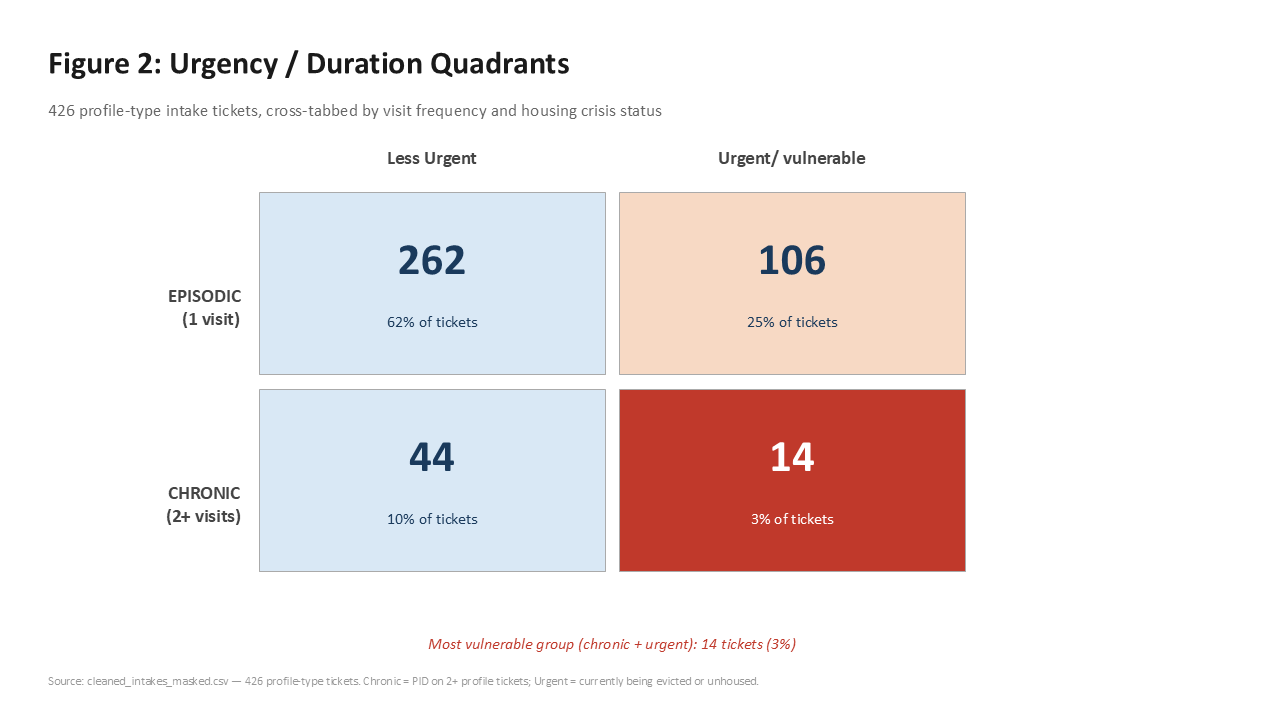

In [ ]:
display(Image('/content/drive/MyDrive/Figure2.png'))

In [ ]:
### Checking the "chronic" proxy: are repeat visits close together or spread out?(will investigate mre in part2)
# Turn the Created column into real dates so we can measure time between visits
profiles["created_dt"] = pd.to_datetime(profiles["Created"], format="%d/%b/%y %I:%M %p")

# Get the list of PIDs that have 2+ profile tickets (our "chronic" group)
pid_counts = profiles["PID"].value_counts()
repeat_pids = pid_counts[pid_counts >= 2].index

# For each repeat PID, sort their visit dates and calculate the number of
# days between each visit and the one before it
gaps = []
for pid in repeat_pids:
    dates = profiles.loc[profiles["PID"] == pid, "created_dt"].sort_values()
    days_between = dates.diff().dropna().dt.days
    gaps.extend(days_between.tolist())

gaps = pd.Series(gaps)

# Summarize: how spread out are these repeat visits?
print(gaps.describe())
print("\nVisits under 14 days apart:", (gaps < 14).sum(), "out of", len(gaps))

count     31.000000
mean      54.032258
std       43.343192
min        0.000000
25%       24.500000
50%       48.000000
75%       74.000000
max      181.000000
dtype: float64

Visits under 14 days apart: 4 out of 31


# What the Data doesn't support:
SLCM's own framework describes three stages of engagement, Reconnect (30-day intake), Rethink (3-6 month programs), and Rebuild (1-5 years of policy work), but our data only supports the first.We searched all 93 columns in cleaned_intakes_masked.csv for any feild representing the diffferent program stages but there were no clear feilds. The only resembling feild was status (19 values describing individual ticket outcomes, like "Referral Only," "Goal Attained," or "Initial Contact") and Status Category (a 3-value Jira workflow bucket: Done, In Progress, To Do). Neither shows us a family's bigger picture with details about a overall engagement has reached, they describe the state of a single ticket, not a multi-month or multi-year journey.As a result, we cannot say how many families who reconnected with SLCM ever advanced into Rethink or Rebuild.

We checked the Relationship field in household_members_long_v2.csv, and found it only records family structure, values like Son, Daughter, Spouse, and Mother, rather than caregiving responsibility or disability status, so we cannot identify caretakers even by combining both files.We would propose SLCM add a "current program stage" field to each case, and a caregiving/disability indicator per household member, to make both parts of their own framework measurable in future

For Figure 2's urgency/duration model, "chronic" and "urgent" are not fields SLCM records directly, we built them ourselves as proxies: PID repeat visits for chronic/episodic, and current eviction/housing status for urgent/not urgent, as the assignment instructs. This works well but has possible limitations.g. The chronic label itself can miscount need: a family that visits twice for two unrelated one-time problems would be labeled "chronic" under this proxy, even though neither individual visit reflects an ongoing, recurring situation.We checked how often this might be happening by measuring the time between visits for the 27 people with 2+ profile tickets: the median gap was 48 days, and only 4 of 31 visit-pairs were less than two weeks apart, suggesting most repeat contact is genuinely spread out over time rather than one crisis being logged twice. Still, this doesn't rule out unrelated repeat visits entirely, since two genuinely separateone-time problems 48 days apart would look identical to one ongoing problem in this data.Our chronic count might include some families who just had bad luck twice, not families with one ongoing struggle, but at least we know it's probably not double-counting the same single crisis, since most repeat visits are weeks or months apart."

## Task 2 — Explore, Clean, and Answer

### 4. Dataset Summary

The cleaned_intakes_masked.csv file has 639 rows and 93 columns.
The household_members_long_v2.csv file has 993 rows and 8 columns.

For the intake dataset, we used the column triage completed in Task 1.
The columns marked "Needed" are used for the main analysis. Columns marked
"Optional" are used when they provide useful context. Columns marked "Drop"
are not used because they are Jira system fields, contain private information,
are duplicate/overflow fields, have too much missing data, or are not relevant
to the five questions.

For the five questions, we focus mainly on profile records. There are 426
profile tickets in the dataset.

In [ ]:
# Task 2 - Step 4: Summarize the datasets


print("CLEANED INTAKES")
print("Profile rows:", profiles.shape[0])
print("Columns:", profiles.shape[1])

print("\nData types:")
print(profiles.dtypes.value_counts())

CLEANED INTAKES
Profile rows: 426
Columns: 96

Data types:
object            85
float64            6
int64              2
bool               2
datetime64[ns]     1
Name: count, dtype: int64


In [ ]:
household = pd.read_csv("/content/drive/MyDrive/household_members_long_v2.csv")

print("HOUSEHOLD MEMBERS")
print("Rows:", household.shape[0])
print("Columns:", household.shape[1])

print("\nData types:")
print(household.dtypes.value_counts())

HOUSEHOLD MEMBERS
Rows: 993
Columns: 8

Data types:
object     6
int64      1
float64    1
Name: count, dtype: int64


The original cleaned intake dataset has 639 rows and 93 columns. For our analysis, we focus mainly on the 426 profile tickets identified in Task 1. The household members dataset has 993 rows and 8 columns. We used the Task 1 column triage as our data dictionary to decide which variables were Needed, Optional, or Drop.

In [ ]:
important_columns = [
    "# Additional Household Members",
    "Age at Intake",
    "Custom field (Employment Status)",
    "Custom field (Eviction Status)",
    "Custom field (Housing Status)",
    "Custom field (Income Amount ($))",
    "Custom field (Monthly Rent ($))",
    "Custom field (Past Due Rent ($))",
    "Custom field (People in Household 17 and Under)",
    "Custom field (People in Household 18+)",
    "Custom field (Source of income)",
    "Custom field (Zip Code)"
]

for col in important_columns:
    print("\n-------------------------")
    print(col)
    print("Missing:", profiles[col].isna().sum())
    print("Unique values:", profiles[col].nunique())
    print(profiles[col].value_counts(dropna=False).head(10))


-------------------------
# Additional Household Members
Missing: 0
Unique values: 9
# Additional Household Members
1    141
3     90
2     85
4     46
0     26
5     20
8      7
7      6
6      5
Name: count, dtype: int64

-------------------------
Age at Intake
Missing: 0
Unique values: 41
Age at Intake
27.0    30
25.0    27
30.0    26
32.0    26
31.0    25
29.0    24
24.0    22
26.0    22
23.0    22
28.0    21
Name: count, dtype: int64

-------------------------
Custom field (Employment Status)
Missing: 0
Unique values: 5
Custom field (Employment Status)
Unemployed but want to find work                       195
Employed                                               118
Employed, but need more hours and/or different work     57
Other                                                   29
Unemployed and not looking for work                     27
Name: count, dtype: int64

-------------------------
Custom field (Eviction Status)
Missing: 0
Unique values: 4
Custom field (Eviction Statu

We explored the important variables selected in Task 1 and checked for missing values, unusual values, and differences in the data. Household size and age at intake were complete, but some housing and financial variables had missing information. There were 426 profile records, and household size varied across families. We also found differences in employment status, housing status, eviction status, income, rent, and ZIP code. Some financial fields had many missing values, so we need to be careful when using them in the analysis. These findings helped us decide what needed cleaning before answering the five questions.

In [ ]:

# Make copies so we do not change the original Task 1 data
profiles_clean = profiles.copy()
household_clean = household.copy()

# 1. Remove extra spaces from text columns
for col in profiles_clean.select_dtypes(include="object").columns:
    profiles_clean[col] = profiles_clean[col].str.strip()

for col in household_clean.select_dtypes(include="object").columns:
    household_clean[col] = household_clean[col].str.strip()

# 2. Keep ZIP code as text/category, not as a number
profiles_clean["Custom field (Zip Code)"] = (
    profiles_clean["Custom field (Zip Code)"]
    .astype("string")
    .str.strip()
)

# 3. Convert important financial fields to numeric
money_columns = [
    "Custom field (Income Amount ($))",
    "Custom field (Monthly Rent ($))",
    "Custom field (Past Due Rent ($))"
]

for col in money_columns:
    profiles_clean[col] = pd.to_numeric(
        profiles_clean[col],
        errors="coerce"
    )

# 4. Check household-member ages for impossible values
invalid_age = (
    (household_clean["Age"] < 0) |
    (household_clean["Age"] > 120)
)

print("Invalid household-member ages:", invalid_age.sum())

# Do not guess the correct age.
# Change impossible ages to missing so they are not used in calculations.
household_clean.loc[invalid_age, "Age"] = pd.NA

print("\nCleaning complete.")
print("Profile records:", len(profiles_clean))
print("Household-member records:", len(household_clean))

Invalid household-member ages: 9

Cleaning complete.
Profile records: 426
Household-member records: 993


We created copies of the datasets before cleaning so the original Task 1 data would not be changed. We removed extra spaces from text values and treated ZIP codes as categories instead of numerical measurements. Income, monthly rent, and past-due rent were converted to numeric values for analysis. We did not replace missing financial values with zero because a missing value does not mean the household had no income or owed no rent. We also checked the household member ages for impossible values. Ages below 0 or above 120 were treated as missing instead of guessing the correct age. All cleaning decisions were documented so the original information was not silently changed.

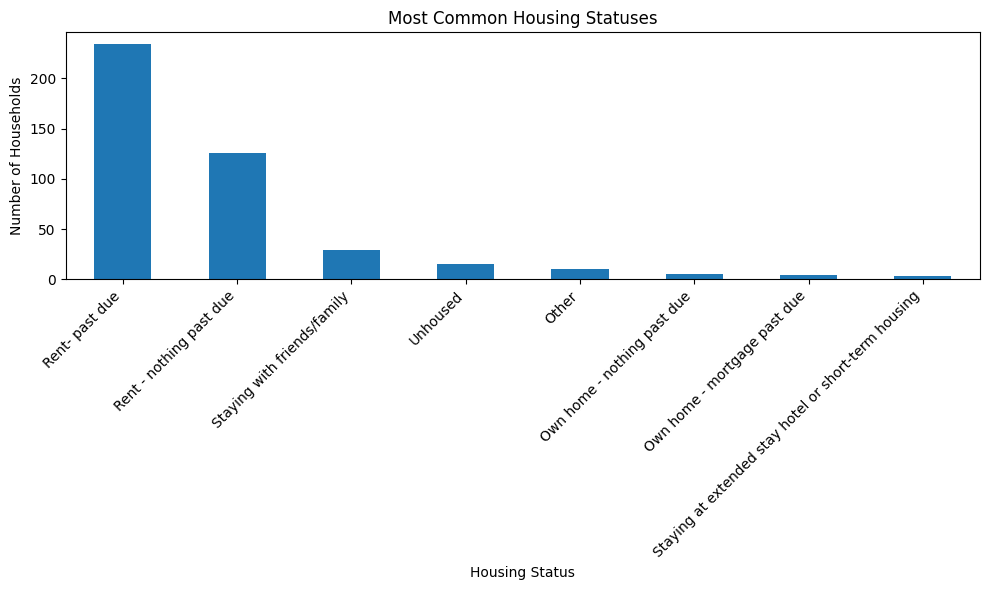

In [ ]:
# Task 2 - Step 7: Plot what we find

import matplotlib.pyplot as plt

# Plot 1: Housing Status
housing_counts = profiles_clean["Custom field (Housing Status)"].value_counts().head(10)

plt.figure(figsize=(10, 6))
housing_counts.plot(kind="bar")
plt.title("Most Common Housing Statuses")
plt.xlabel("Housing Status")
plt.ylabel("Number of Households")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

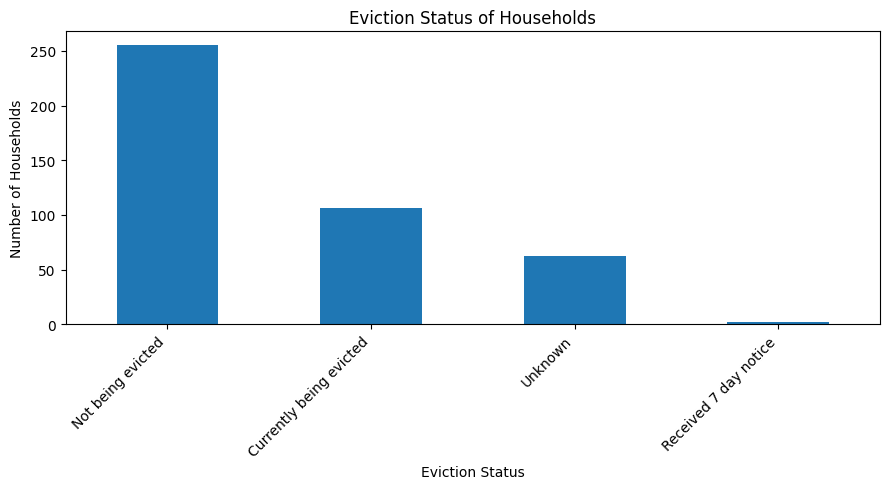

In [ ]:
# Plot 2: Eviction Status

eviction_counts = profiles_clean["Custom field (Eviction Status)"].value_counts()

plt.figure(figsize=(9, 5))
eviction_counts.plot(kind="bar")
plt.title("Eviction Status of Households")
plt.xlabel("Eviction Status")
plt.ylabel("Number of Households")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

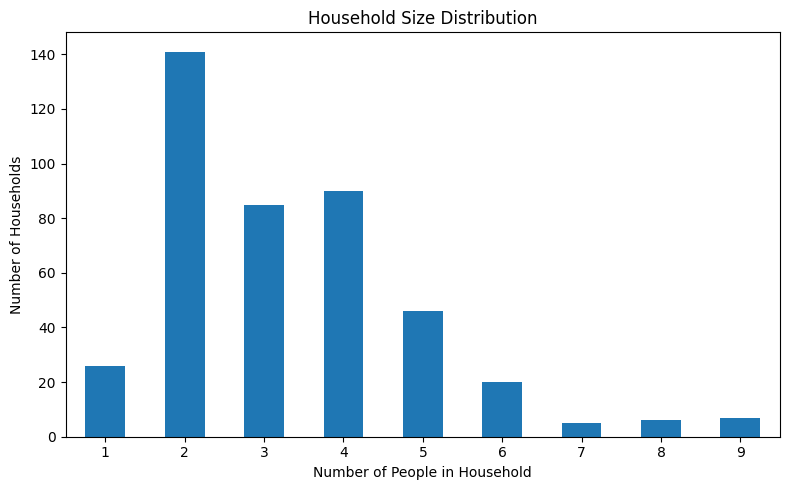

In [ ]:
# Plot 3: Household Size

household_size = profiles_clean["# Additional Household Members"] + 1

plt.figure(figsize=(8, 5))
household_size.value_counts().sort_index().plot(kind="bar")
plt.title("Household Size Distribution")
plt.xlabel("Number of People in Household")
plt.ylabel("Number of Households")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

We created plots to better understand the families in the dataset. We looked at housing status, eviction status, and household size. These variables are important because they show the housing conditions of the population and help us identify households that may be experiencing a housing crisis. The household size plot also helps us understand whether the dataset mostly represents smaller or larger families.

# Question 1:	Housing crisis severity: what share of tickets show active eviction risk (currently being evicted, or unhoused) versus stable housing? Does this differ by zip code or by household size?

In [ ]:
profiles["Zip Clean"] = (
    profiles["Custom field (Zip Code)"]
    .astype("string")
    .str.strip()
    .str.extract(r"(\d{5})", expand=False)
)

print("Cleaned ZIP codes:")
print(profiles["Zip Clean"].value_counts(dropna=False))

Cleaned ZIP codes:
Zip Clean
40214    102
40215     89
40216     30
40208     27
40219     18
40203     17
40118     17
40210     16
40212     15
40211     11
40272      8
40218      8
40217      7
40202      7
40206      6
40299      5
40258      5
40213      5
<NA>       4
40229      4
40245      3
40222      3
40220      3
40059      2
40291      2
40241      2
40209      2
40223      2
40228      2
40207      1
40341      1
40243      1
40107      1
Name: count, dtype: Int64


In [ ]:
from numpy import size
# Step 1: Overall share of families in crisis vs. stable.
# "urgent" already exists from Figure 1 (True = currently being evicted or unhoused).
# normalize=True turns the counts into percentages instead of raw numbers.
print(profiles["urgent"].value_counts(normalize=True))
# Step 2: Does the crisis rate differ by zip code?
# groupby splits the 426 families into groups, one per zip code.
# Taking the mean of a True/False column gives the ppercentage that are True,
# since True counts as 1 and False counts as 0.
zip_crisis_rate = profiles.groupby("Zip Clean")["urgent"].mean()
print("Crisis rate by zip code:")
print(zip_crisis_rate.sort_values(ascending=False))
# Also check how many families are actually in each zip code.
# A "100% crisis rate" based on only 1-2 families isn't a reliable pattern,
# so we need this to know which zip codes to trust.
zip_counts= profiles.groupby("Zip Clean").size()
print("Family count by zip code:")
print(zip_counts.sort_values(ascending=False))
# Step 3: Does the crisis rate differ by household size?
# Same idea as Step 2, but grouped by household size instead of zip code.
size_crisis_rate = profiles.groupby("# Additional Household Members")["urgent"].mean()
size_counts = profiles.groupby("# Additional Household Members").size()
print("\n Crisis rate by household size:")
print(size_crisis_rate)
print("\n Number of families per household size:")
print(size_counts)






urgent
False    0.71831
True     0.28169
Name: proportion, dtype: float64
Crisis rate by zip code:
Zip Clean
40207    1.000000
40228    1.000000
40272    0.750000
40202    0.714286
40220    0.666667
40222    0.666667
40206    0.666667
40245    0.666667
40299    0.600000
40258    0.600000
40212    0.533333
40218    0.500000
40059    0.500000
40291    0.500000
40241    0.500000
40203    0.470588
40210    0.437500
40211    0.363636
40216    0.300000
40219    0.277778
40229    0.250000
40214    0.205882
40213    0.200000
40118    0.176471
40217    0.142857
40215    0.134831
40208    0.111111
40107    0.000000
40209    0.000000
40223    0.000000
40243    0.000000
40341    0.000000
Name: urgent, dtype: float64
Family count by zip code:
Zip Clean
40214    102
40215     89
40216     30
40208     27
40219     18
40203     17
40118     17
40210     16
40212     15
40211     11
40218      8
40272      8
40217      7
40202      7
40206      6
40213      5
40258      5
40299      5
40229      4
402

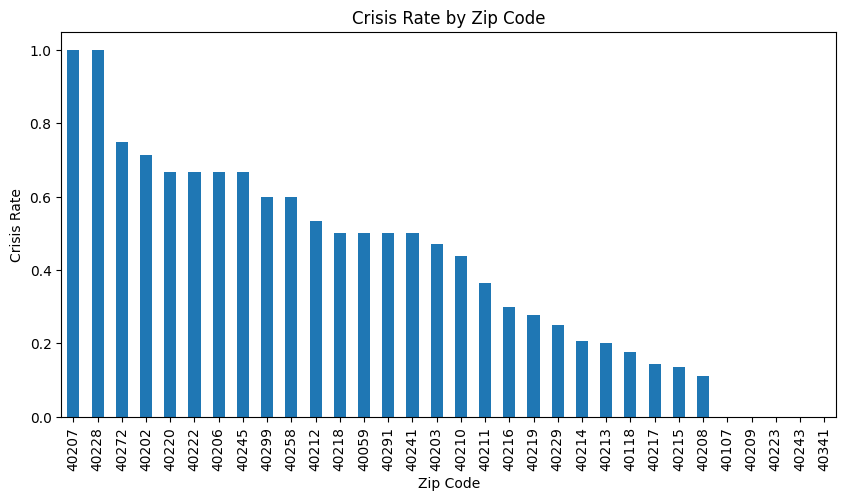

In [ ]:
#step 4 plot the zipcode
import matplotlib.pyplot as plt
zip_crisis_rate.sort_values(ascending=False).plot(kind="bar", figsize=(10, 5))
plt.xlabel("Zip Code")
plt.ylabel("Crisis Rate")
plt.title("Crisis Rate by Zip Code")
plt.show()
plt.show()

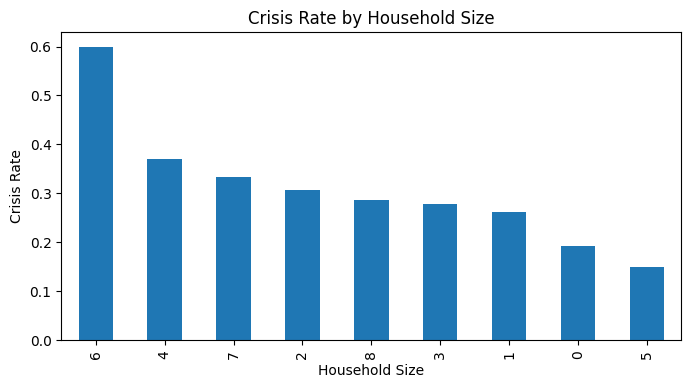

In [ ]:
#step5 Plot the household size
size_crisis_rate.sort_values(ascending=False).plot(kind="bar", figsize=(8, 4))
plt.xlabel("Household Size")
plt.ylabel("Crisis Rate")
plt.title("Crisis Rate by Household Size")
plt.show()

Overall crisis rate: 28.2% of the 426 profile-ticket families show active housing crisis (currently being evicted or unhoused), while 71.8% show stable housing at the time of intake.

By household size: crisis rate generally rises with household size, from 19.2% for households with no additional members to 36.9% for households with 4 additional members. Sizes above 4 (5 through 8 additional members) show more erratic rates (15% to 60%), but each of those groups has only 5-20 families, too few to treat as a reliable pattern.
By zip code: 40214 and 40215 are by far the largest zip codes in the data (102 and 89 families respectively, nearly half of all cases combined) and both show relatively lower crisis rates, 20.6% and 13.5%. Smaller zip codes show more extreme rates in both directions (several at or near 100%, several at 0%), but most of these represent very small samples, often fewer than 10 families, so we treat those as unreliable rather than meaningful geographic differences.
Data quality note: the raw zip code field originally contained ZIP+4 formatting inconsistencies and at least one apparent typo. These were cleaned by standardizing to 5-digit zip codes before this analysis.


## Question 2:	Employment vs. income mismatch: employment status alone doesn't predict financial hardship in this data. Show, with a plot, how income amount and source of income vary between employed and unemployed households.

In [ ]:
 #Look at the actual categories inside Employment Status, so we know
# the real wording before we try to group anything into "employed" vs "unemployed"
print(profiles["Custom field (Employment Status)"].value_counts())

Custom field (Employment Status)
Unemployed but want to find work                       195
Employed                                               118
Employed, but need more hours and/or different work     57
Other                                                   29
Unemployed and not looking for work                     27
Name: count, dtype: int64


In [ ]:
# Group the 5 real categories into 3 buckets: employed, unemployed, and other.
def group_employment(status):
    if status in ["Employed", "Employed, but need more hours and/or different work"]:
        return "Employed"
    elif status in ["Unemployed but want to find work", "Unemployed and not looking for work"]:
        return "Unemployed"
    else:
        return "Other"
 # .apply() runs our function on every row's Employment Status value,
# creating a new column with the simplified group name.
profiles["employment_group"] = profiles['Custom field (Employment Status)'].apply(group_employment)
print(profiles["employment_group"].value_counts())

employment_group
Unemployed    222
Employed      175
Other          29
Name: count, dtype: int64


In [ ]:
# Search for any column with "Income" in its name, to find the exact real spelling
for c in profiles.columns:
    if "Income" in c:
        print(repr(c))

'Custom field (Income Amount ($))'
'Custom field (Loss of Income Causation)'
'Custom field (Loss of Income Causation).1'
'Custom field (Loss of Income Causation).2'
'Custom field (Loss of Income Causation).3'
'Custom field (Rent-to-Income %)'


In [ ]:
# Look at Source of Income specifically for the 29 people marked "Other"
# in employment_group, to see if there's a pattern that explains what
# "Other" means for them (e.g., retired, disabled, self-employed)
print(profiles[profiles["employment_group"] == "Other"]["Custom field (Source of income)"].value_counts())

Custom field (Source of income)
Food benefits - TANF/SNAP     13
No income                      6
Social Security - SSI/SSDI     4
Other                          2
Full-time employment           1
Veterans benefits              1
Pension                        1
Name: count, dtype: int64


**Note on the "Other" employment group:** 29 profiles (7%) fall into an "Other" employment status. Checking their income source shows most rely on food assistance (TANF/SNAP, 13), Social Security (4), veterans benefits, or a pension, rather than traditional employment or job-seeking, suggesting this group largely represents people outside the employed/unemployed framework (e.g., on fixed benefits or disability). One person in this group reported full-time employment despite selecting "Other," which may reflect self-employment or informal work not captured by the standard categories. We excluded this group from the employed-vs-unemployed comparison below, since it represents a genuinely different population rather than ambiguous data.

In [ ]:
# Look at Source of Income specifically for the 29 people marked "Other"
# to see if there's a pattern that explains what "Other" means for them
income_by_employment = profiles[profiles["employment_group"] != "Other"].groupby("employment_group")["Custom field (Income Amount ($))"].describe()
print(income_by_employment)


                  count         mean          std  min     25%     50%  \
employment_group                                                         
Employed          175.0  2988.130743  6832.036014  0.0  1200.0  2000.0   
Unemployed        222.0   740.011802  3429.493650  0.0     0.0     0.0   

                     75%      max  
employment_group                   
Employed          2600.0  75000.0  
Unemployed         900.0  50000.0  


In [ ]:
# Look at the highest-income rows among employed households,
# to see if $75,000 is a real value or a likely data entry error
top_income = profiles[profiles["employment_group"] == "Employed"].sort_values(
    "Custom field (Income Amount ($))", ascending=False
)
print(top_income[["Custom field (Income Amount ($))", "Custom field (Employment Status)", "Custom field (Monthly Rent ($))"]].head(10))

     Custom field (Income Amount ($)) Custom field (Employment Status)  \
541                           75000.0                         Employed   
102                           30000.0                         Employed   
181                           29000.0                         Employed   
532                           29000.0                         Employed   
126                           24000.0                         Employed   
244                            9000.0                         Employed   
342                            5424.0                         Employed   
636                            5126.0                         Employed   
444                            5000.0                         Employed   
471                            4233.0                         Employed   

     Custom field (Monthly Rent ($))  
541                              NaN  
102                              NaN  
181                              NaN  
532                          

In [ ]:
# Compare where income actually comes from, for employed vs unemployed households.
# We exclude "Other" for the same reason as before, it's a distinct population.
income_source_by_group = profiles[profiles["employment_group"] != "Other"].groupby(
    ["employment_group", "Custom field (Source of income)"]
).size()

print(income_source_by_group)

employment_group  Custom field (Source of income)
Employed          Food benefits - TANF/SNAP           54
                  Full-time employment                76
                  No income                            2
                  Other                                8
                  Part-time employment                35
Unemployed        Food benefits - TANF/SNAP          111
                  Full-time employment                 9
                  No income                           71
                  Other                                6
                  Part-time employment                 3
                  Pension                              1
                  Social Security - SSI/SSDI          18
dtype: int64


In [ ]:
# Compare income sources as PERCENTAGES within each employment group.
# Raw counts are hard to compare because the groups are different sizes
# (175 employed vs 222 unemployed), so we convert to shares of each group.

# Keep only Employed and Unemployed (exclude "Other", as before)
two_groups = profiles[profiles["employment_group"] != "Other"]

# crosstab builds a table with employment group as rows and income source
# as columns. normalize="index" turns each row into percentages that add
# up to 100% within that employment group.
source_pct = pd.crosstab(
    two_groups["employment_group"],
    two_groups["Custom field (Source of income)"],
    normalize="index"
) * 100   # multiply by 100 to show percentages instead of decimals

# Round to 1 decimal place so it's easy to read
print(source_pct.round(1))

Custom field (Source of income)  Food benefits - TANF/SNAP  \
employment_group                                             
Employed                                              30.9   
Unemployed                                            50.7   

Custom field (Source of income)  Full-time employment  No income  Other  \
employment_group                                                          
Employed                                         43.4        1.1    4.6   
Unemployed                                        4.1       32.4    2.7   

Custom field (Source of income)  Part-time employment  Pension  \
employment_group                                                 
Employed                                         20.0      0.0   
Unemployed                                        1.4      0.5   

Custom field (Source of income)  Social Security - SSI/SSDI  
employment_group                                             
Employed                                                0.0  

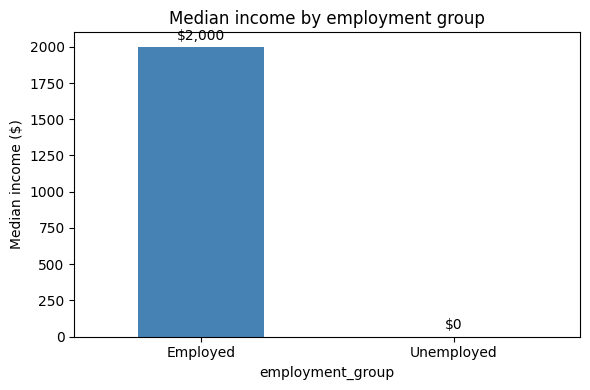

In [ ]:
#fix chart size
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
median_income = two_groups.groupby("employment_group")["Custom field (Income Amount ($))"].median()

median_income.plot(kind="bar", figsize=(6, 4), color=["steelblue", "darkorange"])
plt.bar_label(plt.gca().containers[0], labels=[f"${v:,.0f}" for v in median_income], padding=3)
plt.title("Median income by employment group")
plt.ylabel("Median income ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

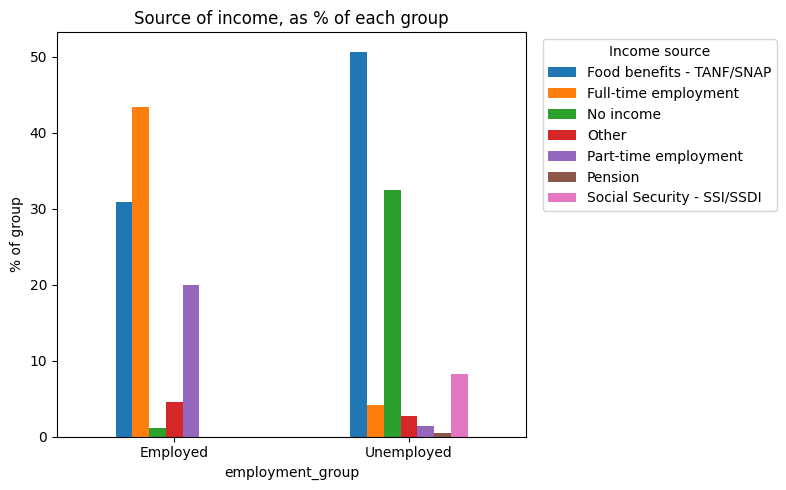

In [ ]:
source_pct.plot(kind="bar", figsize=(8, 5))
plt.title("Source of income, as % of each group")
plt.ylabel("% of group")
plt.xticks(rotation=0)
plt.legend(title="Income source", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Employed households report a higher median income ($2,000/month) than unemployed households ($0/month). However, employment status alone does not predict financial stability: 30.9% of employed households still rely on food benefits (TANF/SNAP) as an income source, compared to 50.7% of unemployed households. Unemployed households are far more likely to report no income at all, 32.4% versus just 1.1% for employed households.A few things are worth keeping in mind about this comparison. We excluded 29 profiles (7%) with an "Other" employment status, since their income sources were mostly Social Security, food benefits, or no income at all, suggesting this group represents people outside the employed/unemployed framework entirely.We also used median instead of mean income, since a handful of very high, round-number values among employed households, $75,000, $30,000, and $29,000, appear to be annual salaries entered into what should have been a monthly income field. These skew the mean upward, while the median isn't affected by them. Finally, three unemployed households had no income source listed and were left out of the income-source percentages, so those percentages reflect 219 households rather than the full 222.


# Question 3:	Household composition: what does the typical household look like in this data (household size, number of children, ages)? Use household_members_long_v2.csv to describe the additional family members, not just the primary contact

In [ ]:
# Question 3: Household Composition

import pandas as pd
import matplotlib.pyplot as plt

# Household size = intake person + additional household members
profiles_clean["Household Size"] = (
    pd.to_numeric(
        profiles_clean["# Additional Household Members"],
        errors="coerce"
    ) + 1
)

# Number of children
profiles_clean["Number of Children"] = pd.to_numeric(
    profiles_clean["Custom field (People in Household 17 and Under)"],
    errors="coerce"
)

print("HOUSEHOLD SIZE")
print("Average:", round(profiles_clean["Household Size"].mean(), 2))
print("Median:", profiles_clean["Household Size"].median())
print("Minimum:", profiles_clean["Household Size"].min())
print("Maximum:", profiles_clean["Household Size"].max())

print("\nNUMBER OF CHILDREN")
print("Average:", round(profiles_clean["Number of Children"].mean(), 2))
print("Median:", profiles_clean["Number of Children"].median())
print("Minimum:", profiles_clean["Number of Children"].min())
print("Maximum:", profiles_clean["Number of Children"].max())

print("\nHOUSEHOLD MEMBER AGES")
print("Average age:", round(household_clean["Age"].mean(), 2))
print("Median age:", household_clean["Age"].median())
print("Minimum age:", household_clean["Age"].min())
print("Maximum age:", household_clean["Age"].max())

print("\nRELATIONSHIPS")
print(household_clean["Relationship"].value_counts(dropna=False).head(10))

HOUSEHOLD SIZE
Average: 3.33
Median: 3.0
Minimum: 1
Maximum: 9

NUMBER OF CHILDREN
Average: 2.16
Median: 2.0
Minimum: 0.0
Maximum: 5.0

HOUSEHOLD MEMBER AGES
Average age: 9.37
Median age: 6.0
Minimum age: 0.0
Maximum age: 72.0

RELATIONSHIPS
Relationship
NaN          361
Son          314
Daughter     248
Spouse        10
Husband        7
Mother         6
Grandson       6
Boyfriend      4
Wife           3
Fiancé         3
Name: count, dtype: int64


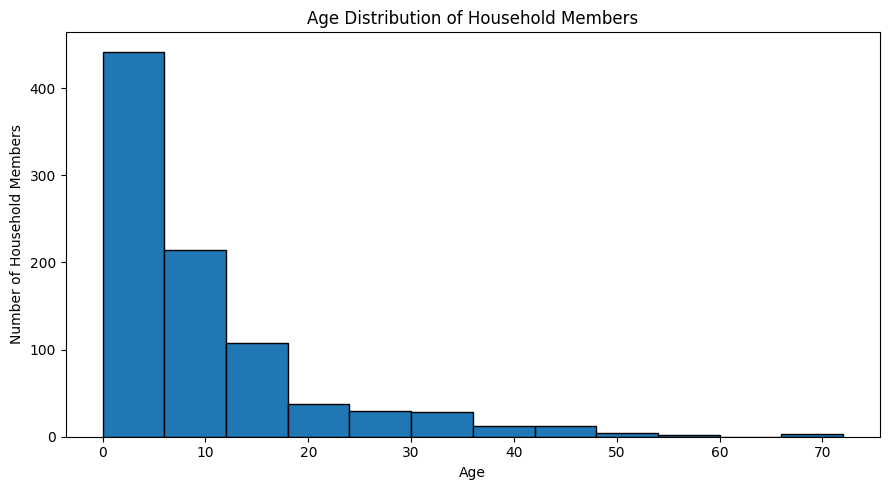

In [ ]:
# Age distribution of additional household members

ages = household_clean["Age"].dropna()

plt.figure(figsize=(9, 5))
plt.hist(ages, bins=12, edgecolor="black")

plt.title("Age Distribution of Household Members")
plt.xlabel("Age")
plt.ylabel("Number of Household Members")

plt.tight_layout()
plt.show()

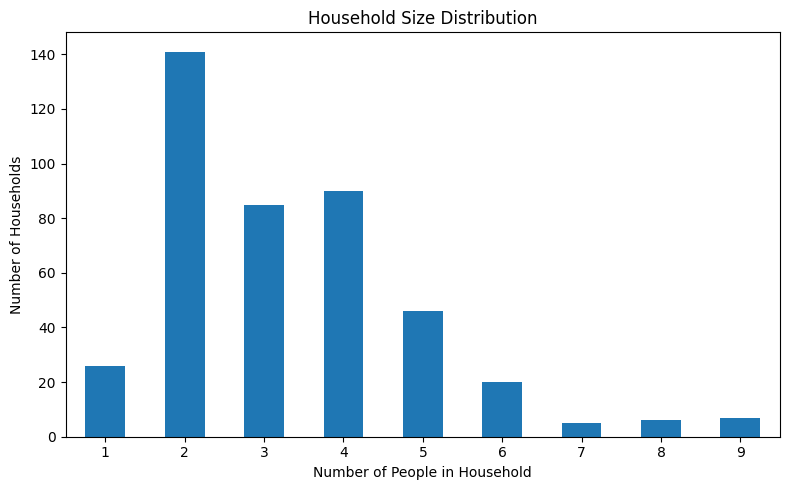

In [ ]:
# Household size distribution

plt.figure(figsize=(8, 5))

profiles_clean["Household Size"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Household Size Distribution")
plt.xlabel("Number of People in Household")
plt.ylabel("Number of Households")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

The typical household in this dataset has about 3 people. The average household size is 3.33, and the median is 3 people. Households range from 1 to 9 people. Families have an average of 2.16 children, with a median of 2 children. The additional household members are mostly young, with an average age of 9.37 and a median age of 6. Most of the identified household members are sons and daughters. Other relationships include spouses, husbands, mothers, grandsons, boyfriends, wives, and fiancés. One limitation is that 361 relationship values are missing, so we cannot fully describe every household.

# Question 4: Repeat contact: using PID, how many people appear on more than one ticket? For people with 2+ tickets, does anything change between their first and most recent ticket (housing status, eviction status)?

In [ ]:
# Question 4: Repeat Contact

# Count how many profile tickets each PID has
pid_counts = profiles_clean["PID"].value_counts()

# Keep people who have 2 or more tickets
repeat_pids = pid_counts[pid_counts >= 2]

print("People with 2+ tickets:", len(repeat_pids))
print("\nNumber of tickets for repeat PIDs:")
print(repeat_pids.value_counts().sort_index())

People with 2+ tickets: 27

Number of tickets for repeat PIDs:
count
2    24
3     2
4     1
Name: count, dtype: int64


In [ ]:
# Get records only for people with 2+ tickets
repeat_records = profiles_clean[
    profiles_clean["PID"].isin(repeat_pids.index)
].copy()

# Make sure Created is a date
repeat_records["Created"] = pd.to_datetime(
    repeat_records["Created"],
    errors="coerce"
)

# Sort tickets from oldest to newest
repeat_records = repeat_records.sort_values(["PID", "Created"])

# Get first and most recent ticket for each PID
first_tickets = repeat_records.groupby("PID").first()
latest_tickets = repeat_records.groupby("PID").last()

housing_col = "Custom field (Housing Status)"
eviction_col = "Custom field (Eviction Status)"

# Compare first vs most recent ticket
comparison = pd.DataFrame({
    "First Housing": first_tickets[housing_col],
    "Latest Housing": latest_tickets[housing_col],
    "First Eviction": first_tickets[eviction_col],
    "Latest Eviction": latest_tickets[eviction_col]
})

comparison["Housing Changed"] = (
    comparison["First Housing"] != comparison["Latest Housing"]
)

comparison["Eviction Changed"] = (
    comparison["First Eviction"] != comparison["Latest Eviction"]
)

print("Repeat-contact people:", len(comparison))

print(
    "Housing status changed:",
    comparison["Housing Changed"].sum()
)

print(
    "Eviction status changed:",
    comparison["Eviction Changed"].sum()
)

display(comparison.head(10))

Repeat-contact people: 27
Housing status changed: 5
Eviction status changed: 8


/tmp/ipykernel_2897/1381744430.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  repeat_records["Created"] = pd.to_datetime(


,First Housing,Latest Housing,First Eviction,Latest Eviction,Housing Changed,Eviction Changed
PID,,,,,,
P0021,Rent- past due,Rent- past due,Unknown,Currently being evicted,False,True
P0025,Rent- past due,Rent- past due,Unknown,Not being evicted,False,True
P0053,Staying with friends/family,Rent- past due,Currently being evicted,Not being evicted,True,True
P0072,Rent - nothing past due,Rent - nothing past due,Not being evicted,Not being evicted,False,False
P0076,Rent- past due,Rent- past due,Unknown,Unknown,False,False
P0081,Rent- past due,Rent- past due,Currently being evicted,Currently being evicted,False,False
P0082,Rent - nothing past due,Rent - nothing past due,Not being evicted,Not being evicted,False,False
P0086,Rent- past due,Rent- past due,Unknown,Currently being evicted,False,True
P0099,Rent- past due,Rent - nothing past due,Not being evicted,Not being evicted,True,False


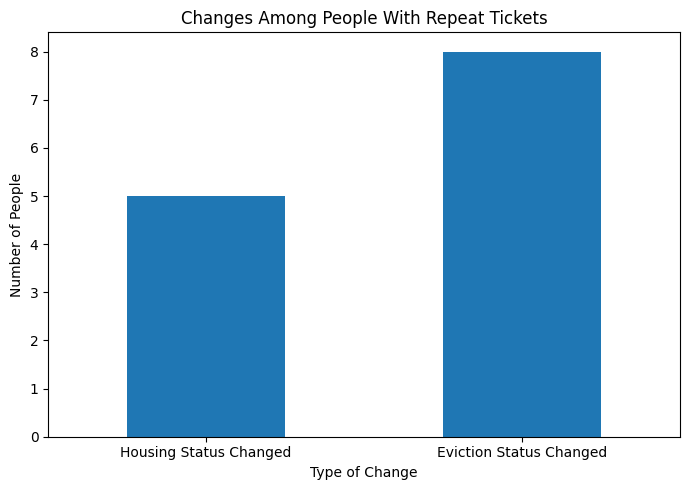

In [ ]:
# Plot changes between first and latest ticket

change_counts = pd.Series({
    "Housing Status Changed": comparison["Housing Changed"].sum(),
    "Eviction Status Changed": comparison["Eviction Changed"].sum()
})

plt.figure(figsize=(7, 5))
change_counts.plot(kind="bar")

plt.title("Changes Among People With Repeat Tickets")
plt.ylabel("Number of People")
plt.xlabel("Type of Change")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

There were 27 people who appeared on two or more profile tickets. When we compared their first ticket to their most recent ticket, 5 people had a change in housing status and 8 people had a change in eviction status. Most repeat-contact households did not have a recorded change in these two fields. This shows that some families' housing situations changed between contacts, but most stayed the same based on the available data.

 **Caveat:**

One limitation is that some statuses are recorded as “Unknown,” so a change in the data does not always mean the family's actual situation became better or worse. It may also mean that more information was available at a later contact.

# Question 5: Data quality: find and document at least two data quality issues in this dataset. Explain how you would handle each one and why.

In [ ]:
# Question 5: Data Quality

print("Missing values in important fields:\n")

check_columns = [
    "Custom field (Housing Status)",
    "Custom field (Eviction Status)",
    "Custom field (Employment Status)",
    "Custom field (Income Amount ($))",
    "Custom field (Zip Code)"
]

for col in check_columns:
    print(col, ":", profiles[col].isna().sum(), "missing")


print("\nDuplicate PIDs:")
print(profiles["PID"].duplicated().sum())


print("\nHousing Status values:")
print(profiles["Custom field (Housing Status)"].value_counts(dropna=False))

print("\nEviction Status values:")
print(profiles["Custom field (Eviction Status)"].value_counts(dropna=False))

Missing values in important fields:

Custom field (Housing Status) : 0 missing
Custom field (Eviction Status) : 0 missing
Custom field (Employment Status) : 0 missing
Custom field (Income Amount ($)) : 0 missing
Custom field (Zip Code) : 3 missing

Duplicate PIDs:
31

Housing Status values:
Custom field (Housing Status)
Rent- past due                                          234
Rent - nothing past due                                 126
Staying with friends/family                              29
Unhoused                                                 15
Other                                                    10
Own home - nothing past due                               5
Own home - mortgage past due                              4
Staying at extended stay hotel or short-term housing      3
Name: count, dtype: int64

Eviction Status values:
Custom field (Eviction Status)
Not being evicted          255
Currently being evicted    106
Unknown                     63
Received 7 day notice  

Issue 1: Unknown eviction status.
There are 63 records where the eviction status is listed as “Unknown.” I would keep these records, but I would not treat them as either being evicted or not being evicted. This prevents us from making assumptions about information we do not know.

Issue 2: Missing ZIP codes.
There are 3 records with missing ZIP codes. I would keep these records for the overall analysis, but leave them out when comparing results by ZIP code. This allows us to still use the other information from these records.

Another data quality issue: There are 31 duplicate PIDs. These should not automatically be deleted because the same person can have more than one ticket. We should use the PID to identify repeat contacts and compare their first and most recent tickets.